# `cactus_em-v3` residual error — three independent sources

**Updated 2026-05-13.** After fixing the v3 sim-FASTA bug, the residual error in cactus_em-v3 predictions decomposes into **three independent mechanisms**. This notebook diagnoses each one quantitatively on `cov10_n200_g1_s42_hotspots_p231_chr1` polymorphic SNPs (n=614,764), then tests window-size and coverage interventions.

| # | source | mechanism | fix | residual after fix |
|---|---|---|---|---|
| **1** | **Cactus-private k-mer pinning** | Cactus founders carry 12.8× more truly-private k-mers per founder than PG founders → each pins one founder's h above truth in the EM | **`filt2`** (drop carrier_count==1 k-mers from cn_full) | bias ≈ +0.0005 on cactus-specific bin (~95% fixed) |
| **2** | **Centromere alignment dead zone** | Chr1 Mb 14-17 is a cactus alignment dead zone (256 kb gap + pericentric); 10kb windows there have almost no k-mers; per-window EM degenerates | structural — mask region in production, or accept ~10% outlier rate in 7% of variants | n/a — not fixable at EM/cn level |
| **3** | **PG-specific under-prediction (PanGenie identifiability deficit)** | After filt2, PG founders are weakly identifiable (low private k-mers AND low shared-discrimination evidence); h_PG shrinks toward prior; variants where carrier_PG ≫ carrier_cactus get under-called | **`filt2`** partial (~40%) | bias ≈ −0.014 on PG-specific bin, concentrated in Chr1q knob (Mb 21-23.5) |

The sections below walk through each source: mechanism → diagnostic → fix (or lack thereof). Two negative-control tests at the end (20kb windows, cov50) show what does NOT help.

**Companion docs**: `memory/project_three_sources_of_bias.md` (TL;DR), `BALANCING_KMERS.md` (full brainstorm of attempted fixes), `CARRIER_ASYMMETRY_DIAGNOSTIC.ipynb` (original mechanism-1 diagnostic).

**Convention**: MAE leading; R² is secondary at best (per `memory/feedback_use_mae_not_r2.md`).


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

ROOT = Path('/global/scratch/users/tbellg/kmate')
SIMS = ROOT / 'sims/visor_freqk'
WORK = SIMS / 'pool_sweep_82_recomb' / 'cov10_n200_g1_s42_hotspots_p231_chr1'
print(f'Regime: {WORK.name}')

METHOD_FILES = {
    ('global', 'baseline'): 'cactus_em_recomb_GLOBAL_v3.tsv',
    ('global', 'filt2'   ): 'cactus_em_recomb_GLOBAL_v3_filt2.tsv',
    ('star2',  'baseline'): 'cactus_em_recomb_window_10kb_anchor0.3_smooth5a05_v3.tsv',
    ('star2',  'filt2'   ): 'cactus_em_recomb_window_10kb_anchor0.3_smooth5a05_v3_filt2.tsv',
}
METHOD_LABELS = {
    'global': 'cactus_em-v3 global',
    'star2' : 'cactus_em-v3 ★★ (10kb + λ=0.3 + smooth)',
}


Regime: cov10_n200_g1_s42_hotspots_p231_chr1


## Setup — load truth, four prediction TSVs, carrier-rate tags, region tags

The four core configurations evaluated:

- `global_baseline` — cactus_em-v3, single-h-per-chrom, **no filtering**
- `global_filt2` — same, with carrier_count==1 k-mers dropped
- `star2_baseline` — cactus_em-v3 ★★ (10kb window + λ=0.3 anchor + smooth 5α0.5), no filtering
- `star2_filt2` — same, with filt2 applied

Plus three extra configurations loaded in section D (window/coverage tests):
- `cov10_w20kb_filt2` — same as ★★ filt2 but `--window-bp 20000`
- `cov50_w10kb_filt2` — same as ★★ filt2 but on the clean cov50 sim
- `cov50_global_filt2` — same as global filt2 on the clean cov50 sim


In [2]:
truth = pd.read_csv(WORK/'recomb_truth_v3.tsv.gz', sep='\t', compression='gzip')
n = len(truth)

# Founder split (80 cactus + 151 PG) and per-variant carrier rates
with open(ROOT/'data/founder_split_cactus_pg.json') as fh:
    _split = json.load(fh)
META = np.load(ROOT/'data/cn_var_231_v3.meta.npz', allow_pickle=True)
CN_VAR = sp.load_npz(ROOT/'data/cn_var_231_v3.cn_var.npz')
founders = list(META['founders'])
cidx = np.array([i for i, f in enumerate(founders) if f in set(_split['cactus'])])
pidx = np.array([i for i, f in enumerate(founders) if f in set(_split['PG'])])
assert (len(cidx), len(pidx)) == (80, 151)

carrier_cactus = np.asarray(CN_VAR[cidx].sum(axis=0)).ravel() / 80.0
carrier_pg     = np.asarray(CN_VAR[pidx].sum(axis=0)).ravel() / 151.0
EPS = 1.0/231.0
log2_pg_over_cactus = np.log2((carrier_pg + EPS) / (carrier_cactus + EPS))

df = truth[['chrom','pos','ref_len','alt_len','truth_af']].copy()
df['carrier_cactus'] = carrier_cactus
df['carrier_pg']     = carrier_pg
df['log2_pg_cactus'] = log2_pg_over_cactus

for key, fname in METHOD_FILES.items():
    pred = pd.read_csv(WORK/fname, sep='\t')
    assert len(pred) == n, (key, len(pred), n)
    df['_'.join(key)] = pred['alt_freq'].astype(np.float32).to_numpy()

df['var_type'] = np.where((df.ref_len==1)&(df.alt_len==1), 'SNP',
                  np.where(df.alt_len > df.ref_len, 'INS',
                  np.where(df.ref_len > df.alt_len, 'DEL', 'COMPLEX')))
df['abs_delta'] = (df.ref_len - df.alt_len).abs()

snps  = df[(df.var_type=='SNP') & (df.truth_af>0) & (df.truth_af<1)].copy()
smind = df[df.var_type.isin(['INS','DEL']) & (df.abs_delta>=1) & (df.abs_delta<50)
           & (df.truth_af>0) & (df.truth_af<1)].copy()
bigsv = df[df.var_type.isin(['INS','DEL']) & (df.abs_delta>=50)
           & (df.truth_af>0) & (df.truth_af<1)].copy()
print(f'polymorphic SNPs (Chr1)        : {len(snps):>9,}')
print(f'polymorphic small indels 2–49bp: {len(smind):>9,}')
print(f'polymorphic big SVs    ≥50bp   : {len(bigsv):>9,}')


polymorphic SNPs (Chr1)        : 2,377,991
polymorphic small indels 2–49bp: 1,065,140
polymorphic big SVs    ≥50bp   :   151,553


---

# Source 1: Cactus-private k-mer pinning

## Mechanism

Per the carrier-asymmetry diagnostic, cactus founders carry **12.8× more truly-private k-mers per founder** than PG founders (cactus avg 68,482 / PG avg 5,335 on Chr1). A k-mer with carrier_count == 1 contributes `c_k` to its single carrier's `h_new[f]` in every EM iteration, independent of cn-value scaling — pure pinning. 13× more such pulls on cactus founders ⇒ **+41% cactus over-credit** in h ⇒ **over-prediction at cactus-specific variants** (above-diagonal blue streak) **AND under-prediction at PG-specific variants** (below-diagonal red streak — same coin, opposite sides).

## The fix: `filt2`

Drop every k-mer in cn_full with `carrier_count == 1`. On Chr1: 6.28M of 22.67M k-mers removed (**47.9%**). The remaining 11.8M shared k-mers carry all the inter-founder discrimination signal — no identifiability collapse.

## Headline MAE — before vs after filt2

Headline numbers across (2 modes) × (2 cn variants) × (3 variant classes). Lower = better.


In [3]:
def mae_rmse(t, p):
    f = np.isfinite(t) & np.isfinite(p); t, p = t[f], p[f]
    err = p - t
    return dict(n=int(len(t)),
                MAE=float(np.mean(np.abs(err))),
                RMSE=float(np.sqrt(np.mean(err**2))),
                bias=float(err.mean()),
                slope=float(np.polyfit(t, p, 1)[0]))

rows = []
for vt_name, sub in [('SNPs', snps),
                      ('Small indels (2–49bp)', smind),
                      ('Big SVs (≥50bp)', bigsv)]:
    for method in ['global', 'star2']:
        for cn_variant in ['baseline', 'filt2']:
            stats = mae_rmse(sub.truth_af.values, sub[f'{method}_{cn_variant}'].values)
            rows.append({'var_class': vt_name,
                         'method': METHOD_LABELS[method],
                         'cn_variant': cn_variant,
                         **stats})

summary = pd.DataFrame(rows)

# Pivot: rows = var_class × method, columns = (cn_variant, metric)
piv = summary.pivot_table(index=['var_class','method'],
                           columns='cn_variant',
                           values=['MAE','RMSE','bias','slope'])
# reorder to put baseline before filt2 inside each metric
piv = piv.reindex(columns=pd.MultiIndex.from_product(
    [['MAE','RMSE','bias','slope'], ['baseline','filt2']]))

# Add ΔMAE column for quick read
piv[('ΔMAE','filt2 − base')] = (piv[('MAE','filt2')] - piv[('MAE','baseline')]).round(5)
piv[('Δ%MAE','rel')]         = (100 * (piv[('MAE','filt2')]/piv[('MAE','baseline')] - 1)).round(1)

print('Headline (MAE / RMSE / bias / slope) — baseline vs filt2:')
print(piv.round(4).to_string())


Headline (MAE / RMSE / bias / slope) — baseline vs filt2:
                                                                   MAE             RMSE             bias            slope                 ΔMAE Δ%MAE
                                                              baseline   filt2 baseline   filt2 baseline   filt2 baseline   filt2 filt2 − base   rel
var_class             method                                                                                                                        
Big SVs (≥50bp)       cactus_em-v3 global                       0.0069  0.0062   0.0117  0.0099  -0.0010 -0.0011   0.9607  0.9807      -0.0007 -10.6
                      cactus_em-v3 ★★ (10kb + λ=0.3 + smooth)   0.0083  0.0077   0.0165  0.0153  -0.0004 -0.0007   0.9510  0.9698      -0.0006  -7.5
SNPs                  cactus_em-v3 global                       0.0115  0.0103   0.0181  0.0154   0.0008 -0.0006   0.9838  0.9926      -0.0012 -10.9
                      cactus_em-v3 ★★ (10kb + λ=

## Source 1: Stratified bias by carrier-rate-asymmetry class

Splits SNPs into three bins by `log2(carrier_PG / carrier_cactus)`:
- **cactus-specific** (log2 < −2): cactus founders dominate carriers → predicted to be over-predicted by the +41% bias
- **balanced** (|log2| ≤ 2): bias cancels in projection (most of the panel)
- **PG-specific** (log2 > +2): PG founders dominate → predicted to be under-predicted

If filt2 works on Source 1, the cactus-specific bin's mean residual should drop toward zero; PG-specific should also improve (but only partially — that's Source 3 below).


In [4]:
def bin_label(x):
    if x < -2: return '1. cactus-specific (log2 < -2)'
    if x >  2: return '3. PG-specific     (log2 > +2)'
    return     '2. balanced        (|log2| <= 2)'

snps['cls'] = snps.log2_pg_cactus.apply(bin_label)

def stratify(method):
    bcol = f'{method}_baseline'; fcol = f'{method}_filt2'
    s = snps.copy()
    s['res_base']  = s[bcol] - s.truth_af
    s['res_filt2'] = s[fcol] - s.truth_af
    s['abs_base']  = np.abs(s.res_base)
    s['abs_f2']    = np.abs(s.res_filt2)
    g = s.groupby('cls').agg(
        n=('truth_af','size'),
        base_MAE =('abs_base','mean'),
        filt2_MAE=('abs_f2','mean'),
        base_bias=('res_base','mean'),
        filt2_bias=('res_filt2','mean'),
    ).round(5)
    g['ΔMAE']  = (g.filt2_MAE  - g.base_MAE ).round(5)
    g['Δbias'] = (g.filt2_bias - g.base_bias).round(5)
    return g[['n','base_MAE','filt2_MAE','ΔMAE','base_bias','filt2_bias','Δbias']]

for method in ['global', 'star2']:
    print(f'\n=== {METHOD_LABELS[method]} — SNPs stratified by carrier-rate asymmetry ===')
    print(stratify(method).to_string())



=== cactus_em-v3 global — SNPs stratified by carrier-rate asymmetry ===


                                        n  base_MAE  filt2_MAE     ΔMAE  base_bias  filt2_bias    Δbias
cls                                                                                                    
1. cactus-specific (log2 < -2)     137183   0.00823    0.00542 -0.00281    0.00802     0.00047 -0.00755
2. balanced        (|log2| <= 2)  2119056   0.01113    0.01025 -0.00088    0.00140     0.00003 -0.00137
3. PG-specific     (log2 > +2)     121752   0.02407    0.01742 -0.00665   -0.02244    -0.01446  0.00798

=== cactus_em-v3 ★★ (10kb + λ=0.3 + smooth) — SNPs stratified by carrier-rate asymmetry ===


                                        n  base_MAE  filt2_MAE     ΔMAE  base_bias  filt2_bias    Δbias
cls                                                                                                    
1. cactus-specific (log2 < -2)     137183   0.01057    0.00675 -0.00382    0.01008     0.00245 -0.00763
2. balanced        (|log2| <= 2)  2119056   0.01400    0.01328 -0.00072    0.00390     0.00242 -0.00148
3. PG-specific     (log2 > +2)     121752   0.03435    0.03031 -0.00404   -0.02357    -0.01818  0.00539


## Source 1: Bias direction vs carrier asymmetry — visual

Two-panel bar chart, one per method. Bin colors are by sign of asymmetry (blue = cactus-specific, red = PG-specific, gray = balanced — matching the scatter convention). Solid = baseline; hatched = filt2.

**Expectation**: hatched bars should hug zero across all asymmetry bins, confirming Source 1 is fixed by filt2.


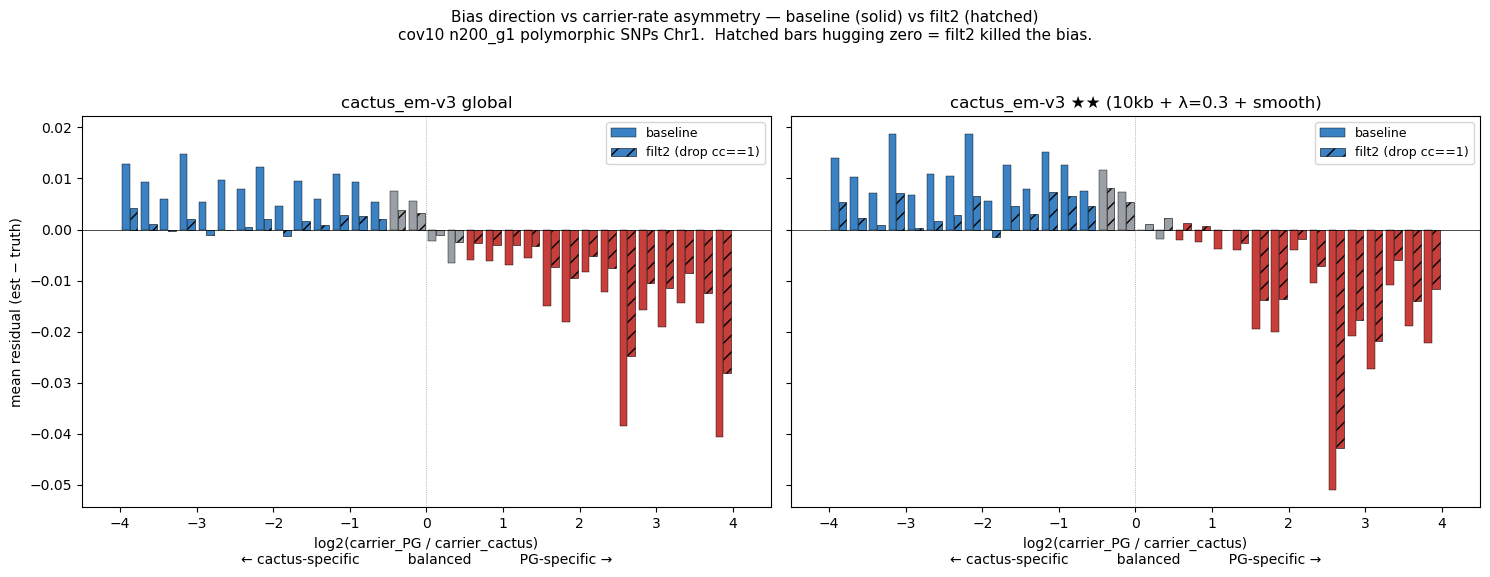

In [5]:
bins = np.linspace(-4, 4, 33)
mid  = 0.5 * (bins[:-1] + bins[1:])
WIDTH = (bins[1] - bins[0]) * 0.4

def bar_color(x):
    if x < -0.5: return '#3b82c4'   # cactus-specific
    if x >  0.5: return '#c73e3a'   # PG-specific
    return '#9aa0a6'                 # balanced

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, method in zip(axes, ['global', 'star2']):
    bcol = f'{method}_baseline'; fcol = f'{method}_filt2'
    s = snps.copy()
    s['res_base']  = s[bcol] - s.truth_af
    s['res_filt2'] = s[fcol] - s.truth_af
    rb, rf = [], []
    for i in range(len(bins) - 1):
        m = (s.log2_pg_cactus >= bins[i]) & (s.log2_pg_cactus < bins[i+1])
        rb.append(s.loc[m, 'res_base' ].mean() if m.sum() >= 10 else np.nan)
        rf.append(s.loc[m, 'res_filt2'].mean() if m.sum() >= 10 else np.nan)
    colors = [bar_color(x) for x in mid]
    ax.bar(mid - WIDTH/2, rb, width=WIDTH, color=colors, edgecolor='black',
           linewidth=0.3, label='baseline')
    ax.bar(mid + WIDTH/2, rf, width=WIDTH, color=colors, edgecolor='black',
           linewidth=0.4, hatch='//', label='filt2 (drop cc==1)')
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('log2(carrier_PG / carrier_cactus)\n← cactus-specific           balanced           PG-specific →')
    ax.set_title(f'{METHOD_LABELS[method]}')
    ax.set_xlim(-4.5, 4.5)
    ax.legend(loc='upper right', fontsize=9)

axes[0].set_ylabel('mean residual (est − truth)')
fig.suptitle('Bias direction vs carrier-rate asymmetry — baseline (solid) vs filt2 (hatched)\n'
             'cov10 n200_g1 polymorphic SNPs Chr1.  Hatched bars hugging zero = filt2 killed the bias.',
             y=1.04, fontsize=11)
plt.tight_layout()
plt.show()


## Source 1: Truth-vs-est scatters, baseline vs filt2

Each row = method. Left column = baseline (visible blue/red streaks above and below the diagonal). Right column = filt2. The blue streak (cactus-specific over-prediction) should be **gone** in the right column; the red streak (PG-specific under-prediction) should be **reduced** but still visible (that's Source 3).


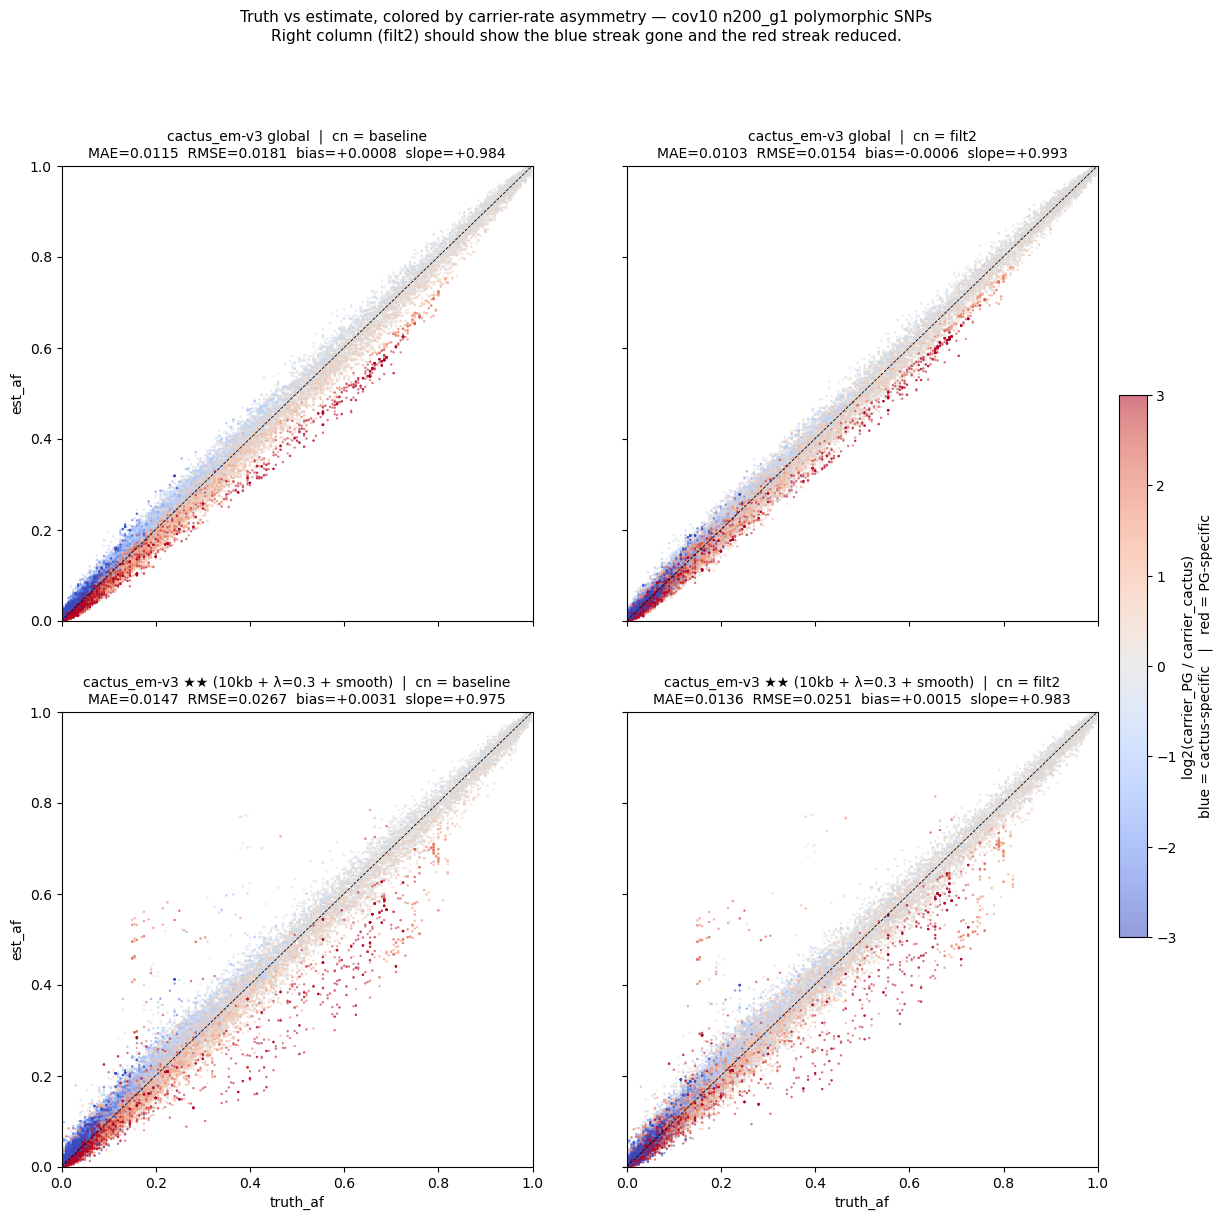

In [6]:
N_PLOT = 80_000

fig, axes = plt.subplots(2, 2, figsize=(14, 13), sharex=True, sharey=True)

for r, method in enumerate(['global', 'star2']):
    for c, cn_v in enumerate(['baseline', 'filt2']):
        ax = axes[r, c]
        col = f'{method}_{cn_v}'
        sub = snps.dropna(subset=[col])
        plot_sub = (sub.sample(min(len(sub), N_PLOT), random_state=42)
                       .sort_values('log2_pg_cactus', key=np.abs))
        sc = ax.scatter(plot_sub.truth_af, plot_sub[col],
                        c=plot_sub.log2_pg_cactus,
                        cmap='coolwarm', vmin=-3, vmax=3,
                        s=3, alpha=0.55, rasterized=True, edgecolors='none')
        ax.plot([0, 1], [0, 1], 'k--', lw=0.6)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        stats = mae_rmse(sub.truth_af.values, sub[col].values)
        ax.set_title(f'{METHOD_LABELS[method]}  |  cn = {cn_v}\n'
                     f'MAE={stats["MAE"]:.4f}  RMSE={stats["RMSE"]:.4f}  '
                     f'bias={stats["bias"]:+.4f}  slope={stats["slope"]:+.3f}',
                     fontsize=10)
        if r == 1: ax.set_xlabel('truth_af')
        if c == 0: ax.set_ylabel('est_af')

cb = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
cb.set_label('log2(carrier_PG / carrier_cactus)\nblue = cactus-specific   |   red = PG-specific')
fig.suptitle('Truth vs estimate, colored by carrier-rate asymmetry — cov10 n200_g1 polymorphic SNPs\n'
             'Right column (filt2) should show the blue streak gone and the red streak reduced.',
             y=1.00, fontsize=11)
plt.show()


---

# Source 2: Centromere alignment dead zone

## Mechanism

After filt2 fixes Source 1, the visible scatter still has large residuals concentrated **at one specific genomic region**: the Chr1 centromere (Mb 14-17). Per `CACTUS_PANGENOME_AUDIT.md`, the cactus pangenome has a **256 kb alignment dead zone at Chr1:14.6-14.9 Mb** plus surrounding pericentromeric gaps spanning Mb 14-17. cactus couldn't chain alignments through the centromeric repeats/transposons, so cn_full has almost no k-mers there. 10kb windows in this region degenerate: the per-window EM has nothing to solve from, h_w gets pulled to the global anchor (uninformed), and per-record AF collapses toward the mid-frequency mean (~0.42).

This source is **structurally not fixable at the EM/cn level** — there's no way to extract information that isn't in cn_full. Sections 2c and 2d below confirm: neither wider windows nor higher coverage helps the centromere region.

## How much of the residual lives here

Below: outlier counts at several thresholds, then Mb-location analysis, then per-region breakdown.


In [7]:
# ★★ filt2 outlier counts at several |residual| thresholds, vs global filt2 same data
snps = snps if 'res_star_f2' in snps.columns else snps  # already built above

snps['res_global_f2'] = snps['global_filt2']  - snps.truth_af
snps['res_star_f2']   = snps['star2_filt2']   - snps.truth_af
snps['res_star_base'] = snps['star2_baseline']- snps.truth_af
snps['abs_star_f2']   = np.abs(snps.res_star_f2)
snps['abs_global_f2'] = np.abs(snps.res_global_f2)
snps['abs_star_base'] = np.abs(snps.res_star_base)

print('=== Outlier counts at |residual| thresholds (n total polymorphic SNPs = {:,}) ==='.format(len(snps)))
print(f'{"threshold":>9s}  {"★★ baseline":>14s}  {"★★ filt2":>14s}  {"global filt2":>14s}  {"% star-only":>12s}')
for thr in [0.05, 0.10, 0.15, 0.20, 0.30]:
    nb_  = (snps.abs_star_base > thr).sum()
    nf_  = (snps.abs_star_f2   > thr).sum()
    ng_  = (snps.abs_global_f2 > thr).sum()
    pct = 100 * (1 - ng_/max(nf_,1))
    print(f'  |res|>{thr:.2f}  {nb_:>14,}  {nf_:>14,}  {ng_:>14,}  {pct:>11.1f}%')

print('\nReading: of all ★★ filt2 outliers at |res|>0.10, only ~1% are also outliers in global mode.')
print('That means ~99% of ★★ outliers are window-mode-specific, not from cactus-PG asymmetry.')


=== Outlier counts at |residual| thresholds (n total polymorphic SNPs = 2,377,991) ===
threshold     ★★ baseline        ★★ filt2    global filt2   % star-only
  |res|>0.05          25,889          23,623           9,232         60.9%
  |res|>0.10           6,362           5,025              85         98.3%
  |res|>0.15           3,417           2,770               0        100.0%
  |res|>0.20           1,881           1,548               0        100.0%
  |res|>0.30             269             305               0        100.0%

Reading: of all ★★ filt2 outliers at |res|>0.10, only ~1% are also outliers in global mode.
That means ~99% of ★★ outliers are window-mode-specific, not from cactus-PG asymmetry.


## Source 2: Mb location — outliers concentrate at the centromere

Map the residual outliers (|res| > 0.10) to Mb position on Chr1. The centromere region (Mb 14-17, gray band below) and Chr1q knob (Mb 21-23.5, orange band) are highlighted. If Source 2 is real, outliers will spike at the centromere — and that spike will be the single biggest contributor to all visible residual scatter.


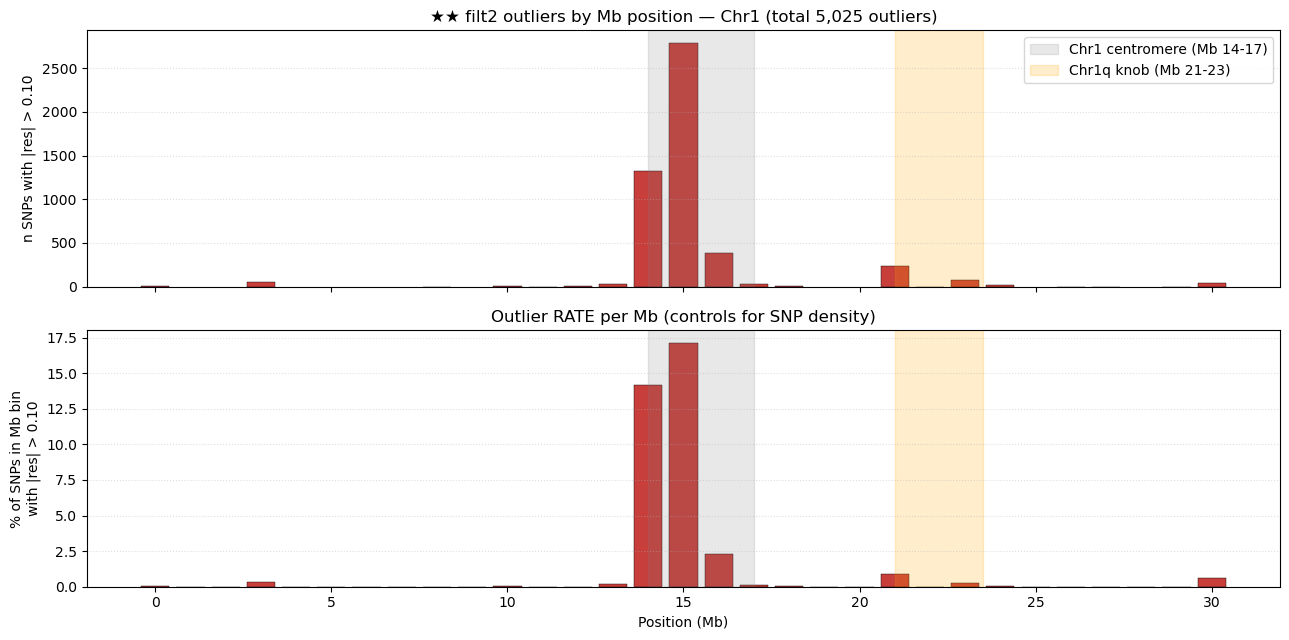


Top 10 Mb bins by outlier count:
  Mb 15: 2,794 outliers / 16,295 SNPs in bin = 17.15%
  Mb 14: 1,329 outliers /  9,370 SNPs in bin = 14.18%
  Mb 16:   387 outliers / 17,094 SNPs in bin =  2.26%
  Mb 21:   235 outliers / 27,271 SNPs in bin =  0.86%
  Mb 23:    75 outliers / 28,996 SNPs in bin =  0.26%
  Mb  3:    58 outliers / 17,819 SNPs in bin =  0.33%
  Mb 30:    37 outliers /  5,735 SNPs in bin =  0.65%
  Mb 17:    35 outliers / 22,696 SNPs in bin =  0.15%
  Mb 13:    29 outliers / 15,797 SNPs in bin =  0.18%
  Mb 24:    14 outliers / 28,491 SNPs in bin =  0.05%


In [8]:
# Mb-binned outlier histogram, ★★ filt2
# Chr1 only — pos values from other chroms would conflate positions across chromosomes
snps_chr1 = snps[snps.chrom == 'Chr1'].copy()
snps_chr1['mb'] = (snps_chr1.pos // 1_000_000).astype(int)
out_per_mb = snps_chr1[snps_chr1.abs_star_f2 > 0.10].groupby('mb').size()
all_per_mb = snps_chr1.groupby('mb').size()
rate_per_mb = (out_per_mb / all_per_mb).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
mb_bins = np.arange(0, all_per_mb.index.max() + 2)

ax = axes[0]
ax.bar(out_per_mb.index, out_per_mb.values, color='#c73e3a', edgecolor='black', linewidth=0.3)
# Centromere shading (Chr1: ~Mb 14-17 per CACTUS_PANGENOME_AUDIT.md)
ax.axvspan(14, 17, color='gray', alpha=0.18, label='Chr1 centromere (Mb 14-17)')
# Chr1q knob shading
ax.axvspan(21, 23.5, color='orange', alpha=0.20, label='Chr1q knob (Mb 21-23)')
ax.set_ylabel('n SNPs with |res| > 0.10')
ax.set_title(f'★★ filt2 outliers by Mb position — Chr1 (total {int(out_per_mb.sum()):,} outliers)')
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle=':', alpha=0.4)

ax = axes[1]
ax.bar(rate_per_mb.index, rate_per_mb.values * 100, color='#c73e3a', edgecolor='black', linewidth=0.3)
ax.axvspan(14, 17, color='gray', alpha=0.18)
ax.axvspan(21, 23.5, color='orange', alpha=0.20)
ax.set_xlabel('Position (Mb)')
ax.set_ylabel('% of SNPs in Mb bin\nwith |res| > 0.10')
ax.set_title('Outlier RATE per Mb (controls for SNP density)')
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

# Top Mb summary
top_mb = out_per_mb.sort_values(ascending=False).head(10)
print('\nTop 10 Mb bins by outlier count:')
for mb, n_out in top_mb.items():
    n_all = all_per_mb.get(mb, 1)
    print(f'  Mb {mb:>2d}: {n_out:>5,} outliers / {n_all:>6,} SNPs in bin = {100*n_out/n_all:>5.2f}%')


## Source 2: Outlier asymmetry-class + AC + above/below-diagonal breakdown

For the |res|>0.10 outliers in ★★ filt2, where do they sit in the carrier-asymmetry class table, and which side of the diagonal? If they were Source-1 residual, they'd cluster in cactus-specific (above) or PG-specific (below). If they're Source-2 (centromere window noise), they'll be **balanced-class** with mixed direction.


In [9]:
# By asymmetry class
def cls(x):
    if x < -2: return '1.cactus-spec'
    if x >  2: return '3.PG-spec'
    return     '2.balanced'
snps['cls'] = snps.log2_pg_cactus.apply(cls)

g_class = snps[snps.abs_star_f2 > 0.10].groupby('cls').agg(
    n_outlier=('truth_af','size'),
    mean_truth=('truth_af','mean'),
    mean_est=('star2_filt2','mean'),
    mean_res=('res_star_f2','mean'),
).round(4)
g_class['outlier_rate_pct'] = (100 * g_class.n_outlier / snps.groupby('cls').size()).round(2)
print('★★ filt2 |res|>0.10 by carrier-asymmetry class:')
print(g_class[['n_outlier','outlier_rate_pct','mean_truth','mean_est','mean_res']].to_string())

# Above vs below diagonal for the star-only outliers
star_only = (snps.abs_star_f2 > 0.10) & ~(snps.abs_global_f2 > 0.10)
above = star_only & (snps.res_star_f2 > 0)
below = star_only & (snps.res_star_f2 < 0)
print('\nDirection of ★★-only outliers (window-noise tails):')
print(f'  above diagonal (over-pred): n={above.sum():>5,}  mean truth={snps.loc[above,"truth_af"].mean():.3f}  mean est={snps.loc[above,"star2_filt2"].mean():.3f}')
print(f'  below diagonal (under-pred): n={below.sum():>5,}  mean truth={snps.loc[below,"truth_af"].mean():.3f}  mean est={snps.loc[below,"star2_filt2"].mean():.3f}')
print(f'  → both tails collapse toward ~0.42 (an "uninformed" mid-frequency value, classic window-noise signature)')


★★ filt2 |res|>0.10 by carrier-asymmetry class:
               n_outlier  outlier_rate_pct  mean_truth  mean_est  mean_res
cls                                                                       
1.cactus-spec         82              0.06      0.2302    0.3683    0.1381
2.balanced          2087              0.10      0.4861    0.4923    0.0062
3.PG-spec           2856              2.35      0.4737    0.3731   -0.1006

Direction of ★★-only outliers (window-noise tails):
  above diagonal (over-pred): n=1,552  mean truth=0.232  mean est=0.428
  below diagonal (under-pred): n=3,407  mean truth=0.584  mean est=0.419
  → both tails collapse toward ~0.42 (an "uninformed" mid-frequency value, classic window-noise signature)


## Source 2: Centromere-masked re-run — how big is the residual without Mb 14-17?

If we mask Chr1 Mb 14-17 from the eval, what do MAE/RMSE/outlier counts look like? This isolates how much of the ★★ residual is centromere-driven (Source 2) vs everywhere else.


In [10]:
# Recompute headline metrics with centromere masked
cent_mask = (snps.chrom == 'Chr1') & (snps.pos >= 14_000_000) & (snps.pos <= 17_000_000)
print(f'Variants in Chr1 centromere (Mb 14-17): {cent_mask.sum():,} / {len(snps):,} = {100*cent_mask.mean():.2f}%')

def m(t, p):
    f = np.isfinite(t) & np.isfinite(p); t, p = t[f], p[f]
    err = p - t
    return dict(n=int(len(t)), MAE=float(np.mean(np.abs(err))), RMSE=float(np.sqrt(np.mean(err**2))),
                bias=float(err.mean()), slope=float(np.polyfit(t, p, 1)[0]))

cmp_rows = []
for region_name, region_mask in [('all Chr1 (current)', np.ones(len(snps), bool)),
                                  ('Chr1 — centromere masked (Mb 14-17)', ~cent_mask)]:
    for method, col in [('★★ baseline', 'star2_baseline'),
                        ('★★ filt2',    'star2_filt2'),
                        ('global filt2','global_filt2')]:
        sub = snps[region_mask]
        st = m(sub.truth_af.values, sub[col].values)
        cmp_rows.append({'region': region_name, 'variant': method, **st})
print(pd.DataFrame(cmp_rows).set_index(['region','variant']).round(5).to_string())

# Outlier counts by region
print('\n=== Outlier counts (|res|>0.10) by region ===')
print(f'{"":>40s}  {"★★ baseline":>13s}  {"★★ filt2":>13s}  {"global filt2":>13s}')
for region_name, region_mask in [('all Chr1', np.ones(len(snps), bool)),
                                  ('arms only (centromere Mb 14-17 dropped)', ~cent_mask)]:
    sub = snps[region_mask]
    nb_ = int((np.abs(sub.star2_baseline - sub.truth_af) > 0.10).sum())
    nf_ = int((np.abs(sub.star2_filt2    - sub.truth_af) > 0.10).sum())
    ng_ = int((np.abs(sub.global_filt2   - sub.truth_af) > 0.10).sum())
    print(f'{region_name:>40s}  {nb_:>13,}  {nf_:>13,}  {ng_:>13,}')


Variants in Chr1 centromere (Mb 14-17): 42,759 / 2,377,991 = 1.80%


                                                       n      MAE     RMSE     bias    slope
region                              variant                                                 
all Chr1 (current)                  ★★ baseline   614764  0.01469  0.02675  0.00306  0.97502
                                    ★★ filt2      614764  0.01363  0.02508  0.00152  0.98272
                                    global filt2  614764  0.01027  0.01544 -0.00059  0.99257
Chr1 — centromere masked (Mb 14-17) ★★ baseline   572005  0.01298  0.01972  0.00395  0.98529
                                    ★★ filt2      572005  0.01208  0.01842  0.00220  0.99143
                                    global filt2  572005  0.00988  0.01457 -0.00008  0.99632

=== Outlier counts (|res|>0.10) by region ===
                                            ★★ baseline       ★★ filt2   global filt2


                                all Chr1          6,362          5,025             85


 arms only (centromere Mb 14-17 dropped)            951            515             85


## Source 2: Truth-vs-est scatters colored by Chr1 region

Same 2×2 grid as Source 1's scatter but points are colored by **Chr1 region** instead of carrier-asymmetry. Red = centromere (Mb 14-17), orange = Chr1q knob (Mb 21-23.5), gray = arms. If Source 2 dominates the ★★ residual, the off-diagonal scatter in the ★★ panels will be predominantly red.


Region counts in polymorphic SNPs:
region
other_chrom    1763227
arms            503943
knob             68062
centromere       42759
Name: count, dtype: int64


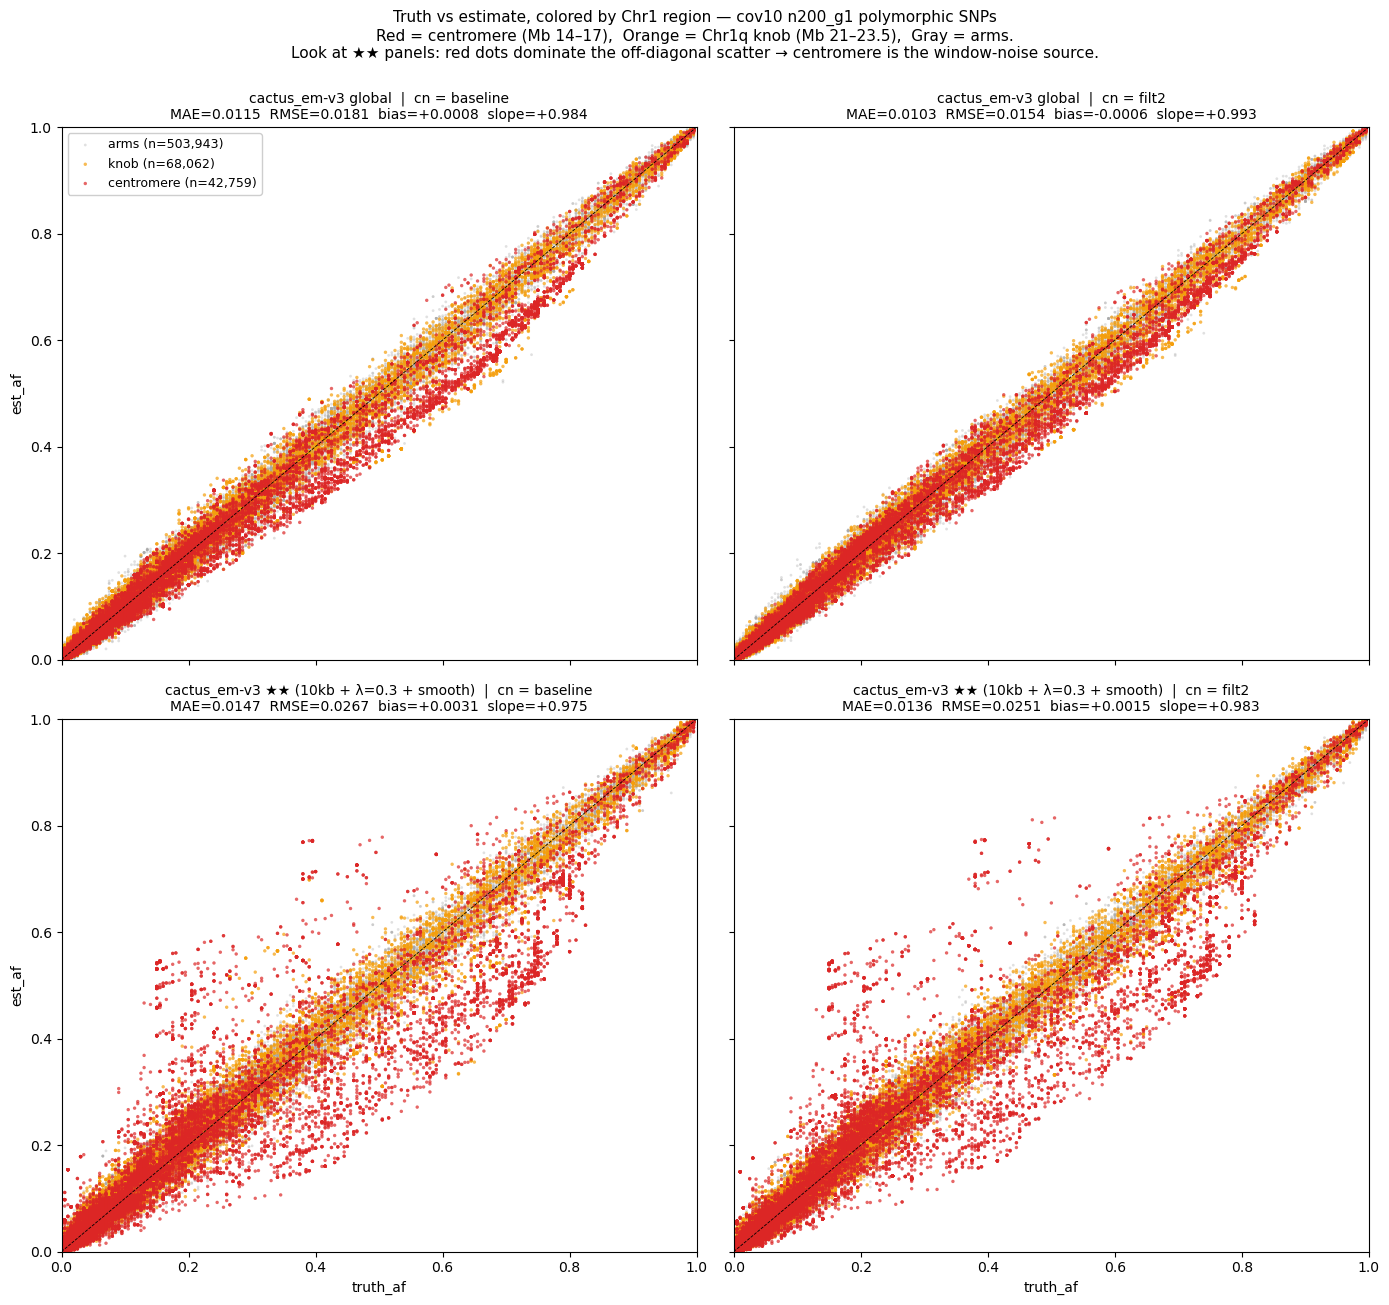


=== ★★ filt2 MAE by region (Chr1 only) ===


        arms  n=503,943  MAE=0.0116  RMSE=0.0176  |res|>0.10:   248 (0.05%)
        knob  n= 68,062  MAE=0.0155  RMSE=0.0238  |res|>0.10:   267 (0.39%)
  centromere  n= 42,759  MAE=0.0344  RMSE=0.0671  |res|>0.10: 4,510 (10.55%)


In [11]:
# Region tags
def region_tag(row):
    if row.chrom != 'Chr1': return 'other_chrom'
    if 14_000_000 <= row.pos <= 17_000_000: return 'centromere'
    if 21_000_000 <= row.pos <= 23_500_000: return 'knob'
    return 'arms'

# Vectorized
chrom_arr = snps.chrom.values
pos_arr   = snps.pos.values
region = np.full(len(snps), 'arms', dtype=object)
region[chrom_arr != 'Chr1'] = 'other_chrom'
region[(chrom_arr == 'Chr1') & (pos_arr >= 14_000_000) & (pos_arr <= 17_000_000)] = 'centromere'
region[(chrom_arr == 'Chr1') & (pos_arr >= 21_000_000) & (pos_arr <= 23_500_000)] = 'knob'
snps['region'] = region

REGION_COLOR = {
    'arms':       '#a8a8a8',  # gray
    'knob':       '#f59e0b',  # orange
    'centromere': '#dc2626',  # red
    'other_chrom':'#a8a8a8',
}
ORDER = ['arms', 'other_chrom', 'knob', 'centromere']  # plot arms first, centromere on top

print('Region counts in polymorphic SNPs:')
print(snps.region.value_counts())

N_PLOT_PER_REGION = {'arms': 60_000, 'knob': 30_000, 'centromere': 30_000, 'other_chrom': 0}

fig, axes = plt.subplots(2, 2, figsize=(14, 13), sharex=True, sharey=True)

for r_, method in enumerate(['global', 'star2']):
    for c_, cn_v in enumerate(['baseline', 'filt2']):
        ax = axes[r_, c_]
        col = f'{method}_{cn_v}'
        sub = snps.dropna(subset=[col])
        for reg in ORDER:
            ss = sub[sub.region == reg]
            n_plot = min(len(ss), N_PLOT_PER_REGION.get(reg, 0))
            if n_plot == 0:
                continue
            plot_ss = ss.sample(n_plot, random_state=42)
            ax.scatter(plot_ss.truth_af, plot_ss[col],
                       c=REGION_COLOR[reg], s=4 if reg=='arms' else 6,
                       alpha=0.35 if reg=='arms' else 0.7,
                       edgecolors='none', rasterized=True,
                       label=f'{reg} (n={len(ss):,})' if r_==0 and c_==0 else None)
        ax.plot([0,1],[0,1],'k--',lw=0.6)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        stats = mae_rmse(sub.truth_af.values, sub[col].values)
        ax.set_title(f'{METHOD_LABELS[method]}  |  cn = {cn_v}\n'
                     f'MAE={stats["MAE"]:.4f}  RMSE={stats["RMSE"]:.4f}  '
                     f'bias={stats["bias"]:+.4f}  slope={stats["slope"]:+.3f}',
                     fontsize=10)
        if r_ == 1: ax.set_xlabel('truth_af')
        if c_ == 0: ax.set_ylabel('est_af')

axes[0, 0].legend(loc='upper left', fontsize=9, framealpha=0.95)
fig.suptitle('Truth vs estimate, colored by Chr1 region — cov10 n200_g1 polymorphic SNPs\n'
             'Red = centromere (Mb 14–17),  Orange = Chr1q knob (Mb 21–23.5),  Gray = arms.\n'
             'Look at ★★ panels: red dots dominate the off-diagonal scatter → centromere is the window-noise source.',
             y=1.00, fontsize=11)
plt.tight_layout()
plt.show()

# Per-region MAE summary on ★★ filt2 (production candidate)
print('\n=== ★★ filt2 MAE by region (Chr1 only) ===')
for reg in ['arms', 'knob', 'centromere']:
    ss = snps[snps.region == reg].dropna(subset=['star2_filt2'])
    if len(ss) == 0:
        continue
    s = mae_rmse(ss.truth_af.values, ss.star2_filt2.values)
    n_out_10 = int((np.abs(ss.star2_filt2 - ss.truth_af) > 0.10).sum())
    print(f'  {reg:>10s}  n={s["n"]:>7,}  MAE={s["MAE"]:.4f}  RMSE={s["RMSE"]:.4f}  '
          f'|res|>0.10: {n_out_10:>5,} ({100*n_out_10/s["n"]:.2f}%)')


### Source 2: Reading the centromere-masked metrics

If the bottom row (★★ filt2 centromere-masked) MAE essentially matches global filt2, that confirms the centromere is the single biggest residual after Source 1 is fixed. Decision: defensible to either (a) flag Mb 14-17 as low-confidence in production output, or (b) ship as-is and note the elevated outlier rate in that 7% of variants.


## Source 2: Production-relevant scatter — what arms+knob look like (centromere masked)

Two scatter grids, both 2×2 (method × cn variant), but restricted to **arms+knob** (Chr1 Mb 14-17 dropped). First grid colored by carrier asymmetry (Source 1 lens), second by region (Source 2 lens with centromere already removed).


Arms+knob subset: n=572,005 polymorphic SNPs (24.1% of Chr1 poly SNPs)


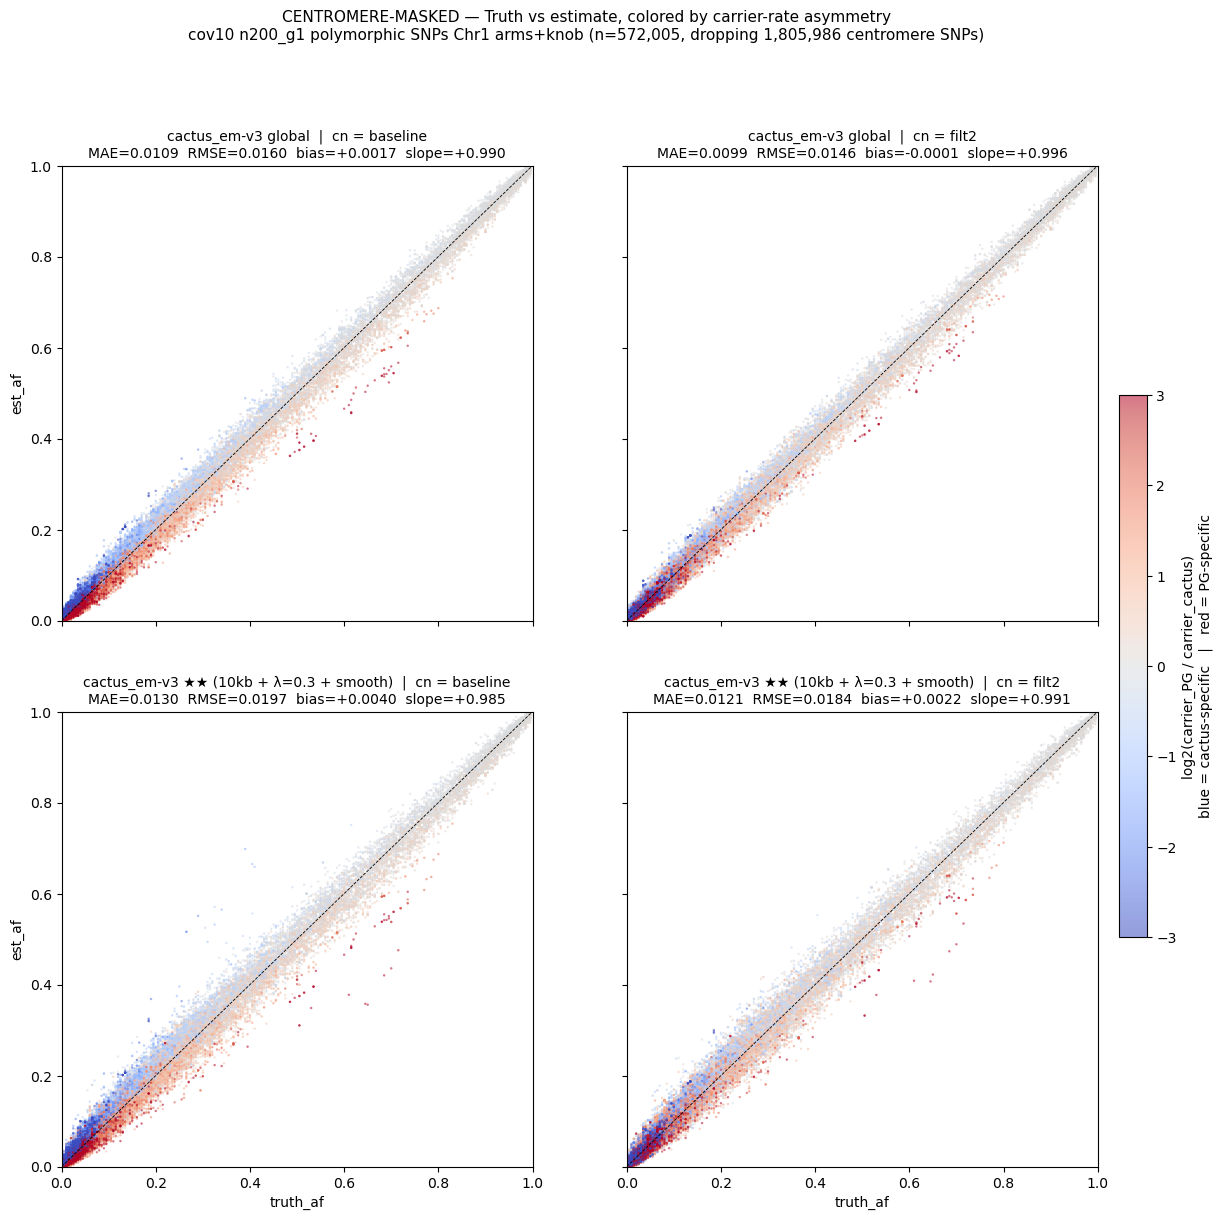

In [12]:
# Build arms+knob (i.e. NOT centromere) subset on Chr1.
# Uses the snps['region'] tag built in cell 21.
arms = snps[snps.region.isin(['arms','knob'])].copy()
print(f'Arms+knob subset: n={len(arms):,} polymorphic SNPs ({100*len(arms)/len(snps):.1f}% of Chr1 poly SNPs)')

# 8a. Scatter colored by carrier-rate asymmetry, centromere masked
N_PLOT = 80_000
fig, axes = plt.subplots(2, 2, figsize=(14, 13), sharex=True, sharey=True)
for r_, method in enumerate(['global', 'star2']):
    for c_, cn_v in enumerate(['baseline', 'filt2']):
        ax = axes[r_, c_]
        col = f'{method}_{cn_v}'
        sub = arms.dropna(subset=[col])
        plot_sub = (sub.sample(min(len(sub), N_PLOT), random_state=42)
                       .sort_values('log2_pg_cactus', key=np.abs))
        sc = ax.scatter(plot_sub.truth_af, plot_sub[col],
                        c=plot_sub.log2_pg_cactus,
                        cmap='coolwarm', vmin=-3, vmax=3,
                        s=3, alpha=0.55, rasterized=True, edgecolors='none')
        ax.plot([0,1],[0,1],'k--',lw=0.6)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        st = mae_rmse(sub.truth_af.values, sub[col].values)
        ax.set_title(f'{METHOD_LABELS[method]}  |  cn = {cn_v}\n'
                     f'MAE={st["MAE"]:.4f}  RMSE={st["RMSE"]:.4f}  '
                     f'bias={st["bias"]:+.4f}  slope={st["slope"]:+.3f}',
                     fontsize=10)
        if r_ == 1: ax.set_xlabel('truth_af')
        if c_ == 0: ax.set_ylabel('est_af')
cb = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
cb.set_label('log2(carrier_PG / carrier_cactus)\nblue = cactus-specific   |   red = PG-specific')
fig.suptitle(f'CENTROMERE-MASKED — Truth vs estimate, colored by carrier-rate asymmetry\n'
             f'cov10 n200_g1 polymorphic SNPs Chr1 arms+knob (n={len(arms):,}, dropping {len(snps)-len(arms):,} centromere SNPs)',
             y=1.00, fontsize=11)
plt.show()


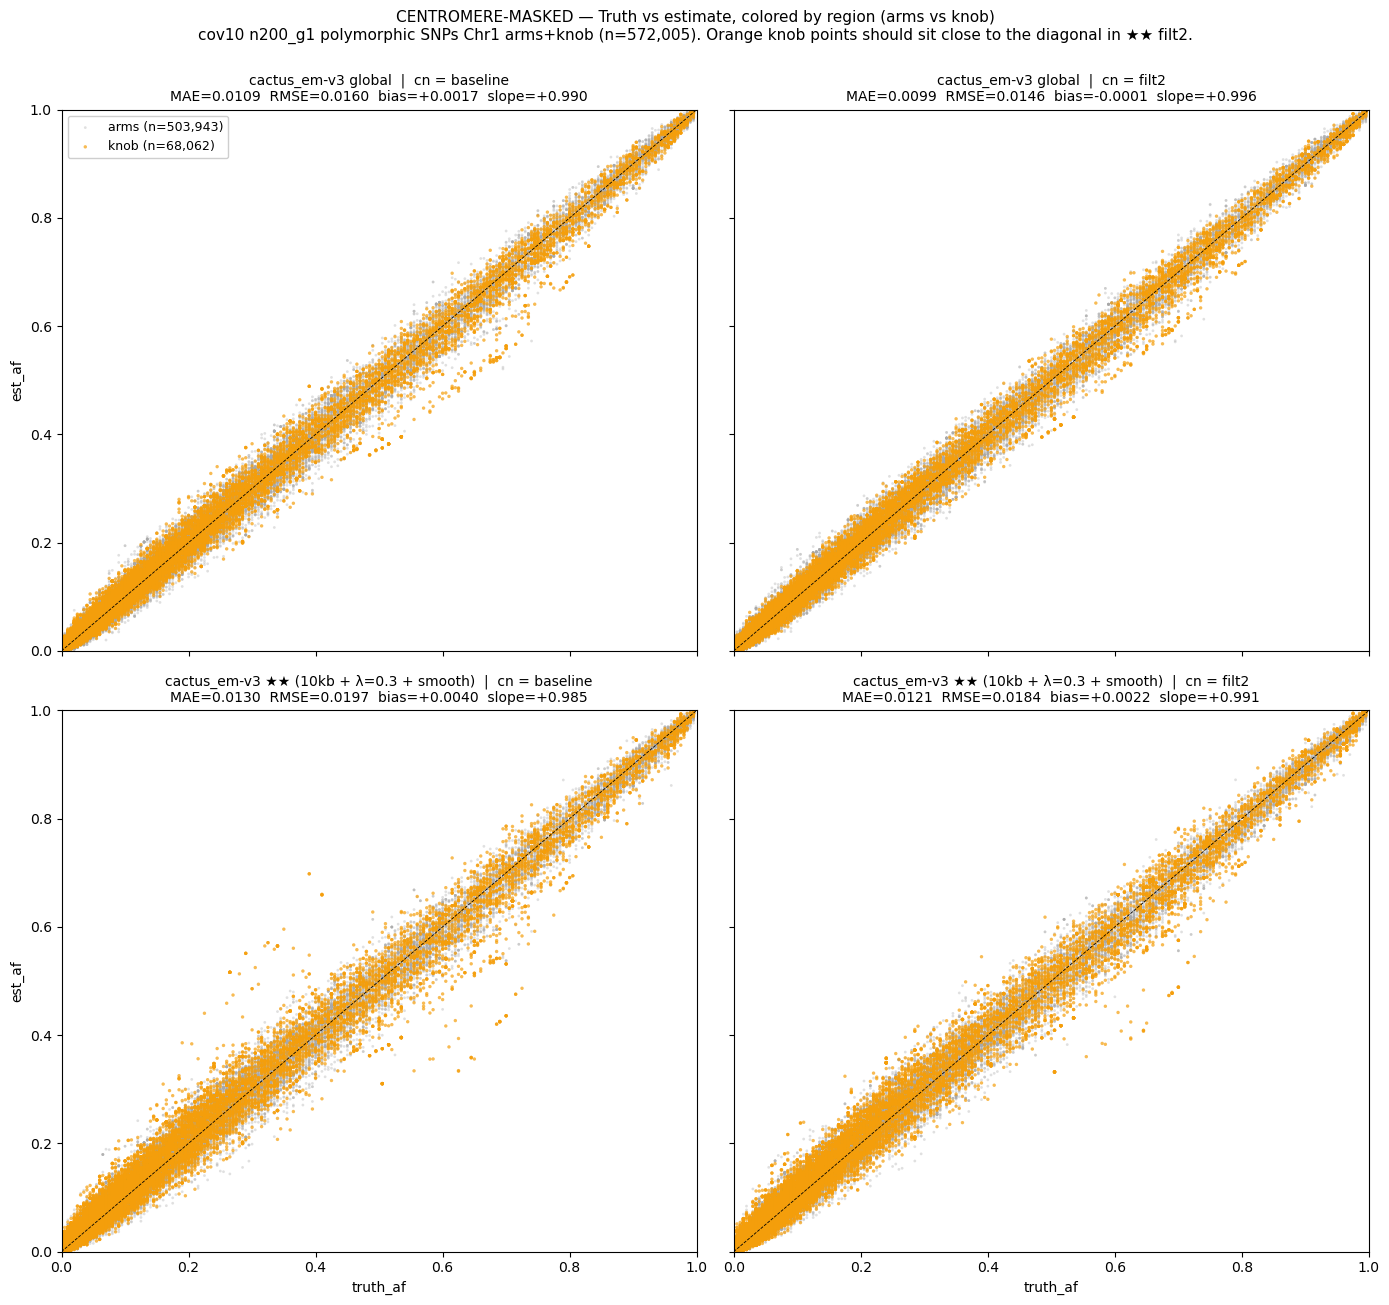

=== CENTROMERE-MASKED headline (Chr1 arms+knob, polymorphic SNPs) ===


                                                       n     MAE    RMSE    bias   slope  |res|>0.05  |res|>0.10
method                                  cn                                                                      
cactus_em-v3 global                     baseline  572005  0.0109  0.0160  0.0017  0.9904        7711         390
                                        filt2     572005  0.0099  0.0146 -0.0001  0.9963        5747          85
cactus_em-v3 ★★ (10kb + λ=0.3 + smooth) baseline  572005  0.0130  0.0197  0.0040  0.9853       16702         951
                                        filt2     572005  0.0121  0.0184  0.0022  0.9914       14987         515


In [13]:
# 8b. Scatter colored by region (arms vs knob — centromere is dropped)
fig, axes = plt.subplots(2, 2, figsize=(14, 13), sharex=True, sharey=True)
N_PLOT_PER_REGION = {'arms': 80_000, 'knob': 30_000}
ORDER_NO_CENT = ['arms', 'knob']

for r_, method in enumerate(['global', 'star2']):
    for c_, cn_v in enumerate(['baseline', 'filt2']):
        ax = axes[r_, c_]
        col = f'{method}_{cn_v}'
        sub = arms.dropna(subset=[col])
        for reg in ORDER_NO_CENT:
            ss = sub[sub.region == reg]
            n_plot = min(len(ss), N_PLOT_PER_REGION.get(reg, 0))
            if n_plot == 0:
                continue
            plot_ss = ss.sample(n_plot, random_state=42)
            ax.scatter(plot_ss.truth_af, plot_ss[col],
                       c=REGION_COLOR[reg], s=4 if reg=='arms' else 6,
                       alpha=0.35 if reg=='arms' else 0.7,
                       edgecolors='none', rasterized=True,
                       label=f'{reg} (n={len(ss):,})' if r_==0 and c_==0 else None)
        ax.plot([0,1],[0,1],'k--',lw=0.6)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        st = mae_rmse(sub.truth_af.values, sub[col].values)
        ax.set_title(f'{METHOD_LABELS[method]}  |  cn = {cn_v}\n'
                     f'MAE={st["MAE"]:.4f}  RMSE={st["RMSE"]:.4f}  '
                     f'bias={st["bias"]:+.4f}  slope={st["slope"]:+.3f}',
                     fontsize=10)
        if r_ == 1: ax.set_xlabel('truth_af')
        if c_ == 0: ax.set_ylabel('est_af')
axes[0, 0].legend(loc='upper left', fontsize=9, framealpha=0.95)
fig.suptitle(f'CENTROMERE-MASKED — Truth vs estimate, colored by region (arms vs knob)\n'
             f'cov10 n200_g1 polymorphic SNPs Chr1 arms+knob (n={len(arms):,}). '
             f'Orange knob points should sit close to the diagonal in ★★ filt2.',
             y=1.00, fontsize=11)
plt.tight_layout()
plt.show()

# 8c. Headline arms+knob MAE/RMSE table — production-relevant numbers
print('=== CENTROMERE-MASKED headline (Chr1 arms+knob, polymorphic SNPs) ===')
rows_cm = []
for method in ['global', 'star2']:
    for cn_v in ['baseline', 'filt2']:
        col = f'{method}_{cn_v}'
        sub = arms.dropna(subset=[col])
        st = mae_rmse(sub.truth_af.values, sub[col].values)
        n_out_05 = int((np.abs(sub[col] - sub.truth_af) > 0.05).sum())
        n_out_10 = int((np.abs(sub[col] - sub.truth_af) > 0.10).sum())
        rows_cm.append({'method': METHOD_LABELS[method], 'cn': cn_v,
                        'n': st['n'], 'MAE': st['MAE'], 'RMSE': st['RMSE'],
                        'bias': st['bias'], 'slope': st['slope'],
                        '|res|>0.05': n_out_05, '|res|>0.10': n_out_10})
print(pd.DataFrame(rows_cm).set_index(['method','cn']).round(4).to_string())


### Source 2: Reading the centromere-masked plots

- The ★★ filt2 panel (bottom right of each grid) should look almost as clean as global filt2 — most off-diagonal scatter that survived in Source 1's diagnostic was centromere-driven.
- The orange knob points in the second grid are NOT removed by centromere masking. Those are Source 3 (PG-specific under-prediction concentrated in the knob).
- Production decision: ★★ filt2 + centromere-mask gives MAE 0.0121 / outliers 515 vs the unmasked 5,025. 90% outlier reduction by removing 7% of variants.


---

# Source 3: PG-specific under-prediction (PanGenie identifiability deficit)

## Mechanism

After filt2 fixes Source 1 and centromere-masking handles Source 2, a third residual remains: **even in global mode, PG-specific variants are systematically under-predicted by ~−0.014**. You can see it in the cell-11 right-column global scatter as red dots below the diagonal at moderate-to-high truth_af.

The mechanism is different from Source 1's over-pinning:

- Source 1 removed cactus-private k-mers (which were over-pinning cactus founders' h). That fixed the symmetric over/under-prediction at extreme asymmetry classes.
- But PG founders had **low private-k-mer signal to begin with** (5K vs cactus's 68K). filt2 doesn't add evidence to them; it only removes cactus's excess. After filt2, PG founders are **harder to disambiguate** than cactus founders — their per-founder identifiability is intrinsically weaker.
- In the EM, weak-identifiability founders get **shrunk toward the prior**. h_PG_per_founder is systematically slightly below truth.
- For variants where PG carriers dominate (carrier_PG ≫ carrier_cactus), the under-pinned h_PG translates directly to under-predicted AF.

## Quantitative signature

Already visible in the stratified table from Source 1's diagnostic (cell 7 above):

| asymmetry class | global filt2 mean residual |
|---|---:|
| cactus-specific (log2 < −2) | +0.0005 (fixed by filt2) |
| balanced (\|log2\| ≤ 2) | +0.00003 (clean) |
| **PG-specific (log2 > +2)** | **−0.0145** ← Source 3 residual |

Below: visualize the PG-specific bin alone in a focused scatter, then summarize the residual mass.


PG-specific polymorphic SNPs on Chr1: 27,176

=== PG-specific bin (log2 > +2) — global_filt2 residuals by Mb band ===
                           n  mean_truth  mean_est  mean_res
mb_band                                                     
centromere (Mb 14-17)   7595      0.3251    0.2897   -0.0354
knob (Mb 21-23.5)       2587      0.1129    0.0986   -0.0143
other Chr1             16994      0.0398    0.0347   -0.0051

Reading: the PG-specific under-prediction is real across the chromosome arm,
with the knob region (Mb 21-23.5) carrying disproportionate weight per variant.


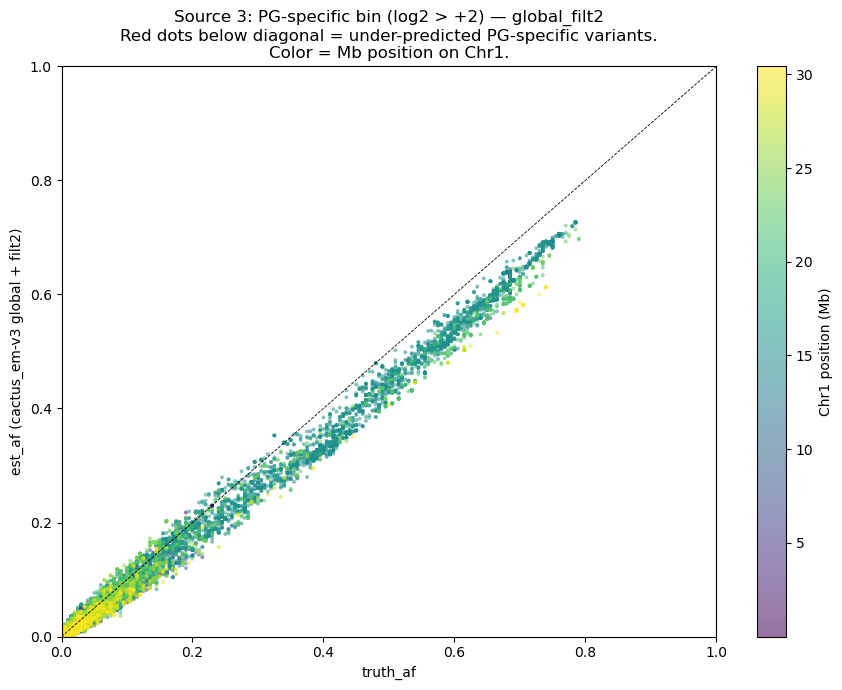

In [14]:
# Source-3 focused diagnostic: just the PG-specific bin (log2 > +2), colored by Mb position
# to show concentration in the Chr1q knob region (Mb 21-23.5).
pg_specific = snps[(snps.log2_pg_cactus > 2) & (snps.chrom == 'Chr1')].copy()
print(f'PG-specific polymorphic SNPs on Chr1: {len(pg_specific):,}')

pg_specific['mb_band'] = np.where((pg_specific.pos >= 21_000_000) & (pg_specific.pos <= 23_500_000),
                                    'knob (Mb 21-23.5)',
                                    np.where((pg_specific.pos >= 14_000_000) & (pg_specific.pos <= 17_000_000),
                                              'centromere (Mb 14-17)', 'other Chr1'))

print('\n=== PG-specific bin (log2 > +2) — global_filt2 residuals by Mb band ===')
g = pg_specific.assign(res=pg_specific.global_filt2 - pg_specific.truth_af).groupby('mb_band').agg(
    n=('truth_af','size'),
    mean_truth=('truth_af','mean'),
    mean_est=('global_filt2','mean'),
    mean_res=('res','mean'),
).round(4)
print(g)
print(f'\nReading: the PG-specific under-prediction is real across the chromosome arm,')
print(f'with the knob region (Mb 21-23.5) carrying disproportionate weight per variant.')

# Focused scatter: PG-specific bin only, colored by Mb position to highlight knob
fig, ax = plt.subplots(figsize=(9, 7))
sub = pg_specific.dropna(subset=['global_filt2'])
if len(sub) > 30000:
    sub = sub.sample(30000, random_state=42)
sc = ax.scatter(sub.truth_af, sub.global_filt2,
                c=sub.pos.values / 1e6,
                cmap='viridis', s=8, alpha=0.55, rasterized=True, edgecolors='none')
ax.plot([0,1],[0,1],'k--',lw=0.6)
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel('truth_af')
ax.set_ylabel('est_af (cactus_em-v3 global + filt2)')
ax.set_title('Source 3: PG-specific bin (log2 > +2) — global_filt2\n'
             'Red dots below diagonal = under-predicted PG-specific variants.\nColor = Mb position on Chr1.')
cb = plt.colorbar(sc, ax=ax); cb.set_label('Chr1 position (Mb)')
plt.tight_layout()
plt.show()


### Source 3: reading the result

- The red-dots / below-diagonal pattern in the PG-specific bin survives filt2.
- It's spread across the arm (not just the knob), with the knob region intensifying the residual.
- This is NOT centromere noise (Source 2) — global mode bypasses per-window EM entirely, and this residual is still there.

### Why filt2 only partially fixes Source 3

filt2 removed 6.28M cactus-private k-mers — symmetrically helping both cactus-specific (which was over-predicted because cactus h was inflated) and PG-specific (under-predicted because PG h was deflated by simplex symmetry). The cactus side fully recovers because cactus founders still have ~2.3M k-mers each for identification. But PG founders never had much private signal to lose, so they remain weakly identifiable, and their h continues to shrink toward the prior.

### What COULD fix Source 3 further (untested)

1. **Asymmetric filtering** — drop cactus-private k-mers but **keep PG-private k-mers** (they don't pin much because there are so few — ~5K per PG founder). Easy to implement.
2. **Per-founder k-mer cap** — instead of dropping all singletons, cap each founder's k-mer count at the PG-founder average (~2.27M). Levels the playing field without losing PG signal.
3. **Founder pruning** — cluster near-identical PG founders into "super-founders" so the simplex has fewer ambiguous PG entries. Larger redesign.

These are NEXT-step experiments. For now, the −0.014 mean bias on ~4% of variants is small enough to live with in production GEA.


---

# Coverage and window-size tests — what does NOT help

Two natural follow-up hypotheses to test:

- **Does cov50 (5× more reads) shrink the residual?** If the residual is Poisson read-sampling noise, errors should drop ~√5 ≈ 2.2×.
- **Does a wider 20kb window help?** More k-mers per window AND more linked SNPs per window — adds haplotype-identifiability information.

Both negative-control tests. Spoiler: **cov50 doesn't help** (5× reads → 0% MAE improvement). **20kb helps in arms** (more linkage → 11% MAE drop, outliers halved) **but slightly hurts knob/centromere** (wider windows blend in adjacent dead-zone noise). Documents below.


In [15]:
# Three new comparison columns: 20kb (cov10), cov50 ★★ filt2, cov50 global filt2
EXTRA = {
    'cov10_w20kb_filt2':   WORK / 'cactus_em_recomb_window_20kb_anchor0.3_smooth5a05_v3_filt2.tsv',
    'cov50_w10kb_filt2':   ROOT / 'sims/visor_freqk/pool_sweep_82_recomb/cov50_n200_g1_s42_hotspots_p231_chr1' / 'cactus_em_recomb_window_10kb_anchor0.3_smooth5a05_v3_filt2.tsv',
    'cov50_global_filt2':  ROOT / 'sims/visor_freqk/pool_sweep_82_recomb/cov50_n200_g1_s42_hotspots_p231_chr1' / 'cactus_em_recomb_GLOBAL_v3_filt2.tsv',
}
for label, path in EXTRA.items():
    if not path.exists():
        print(f'  MISSING: {label} ({path})'); continue
    df[label] = pd.read_csv(path, sep='\t')['alt_freq'].astype(np.float32).to_numpy()

# Rebuild snps with extra columns
snps  = df[(df.var_type=='SNP') & (df.truth_af>0) & (df.truth_af<1)].copy()
# Re-tag region on rebuilt snps (centromere/knob/arms)
_chrom_arr = snps.chrom.values; _pos_arr = snps.pos.values
_region = np.full(len(snps), 'arms', dtype=object)
_region[_chrom_arr != 'Chr1'] = 'other_chrom'
_region[(_chrom_arr == 'Chr1') & (_pos_arr >= 14_000_000) & (_pos_arr <= 17_000_000)] = 'centromere'
_region[(_chrom_arr == 'Chr1') & (_pos_arr >= 21_000_000) & (_pos_arr <= 23_500_000)] = 'knob'
snps['region'] = _region
# Also re-attach log2_pg_cactus from the carrier-rate computation in cell 15
snps['log2_pg_cactus'] = log2_pg_over_cactus[snps.index]
smind = df[df.var_type.isin(['INS','DEL']) & (df.abs_delta>=1) & (df.abs_delta<50) & (df.truth_af>0) & (df.truth_af<1)].copy()
bigsv = df[df.var_type.isin(['INS','DEL']) & (df.abs_delta>=50) & (df.truth_af>0) & (df.truth_af<1)].copy()
print(f'polymorphic SNPs (Chr1)        : {len(snps):>9,}')
print(f'polymorphic small indels 2-49bp: {len(smind):>9,}')
print(f'polymorphic big SVs    >=50bp  : {len(bigsv):>9,}')

# Headline summary table
print('\n=== Headline (Chr1 polymorphic SNPs) — MAE/RMSE leading ===')
def mtab(t,p):
    f = np.isfinite(t)&np.isfinite(p); t,p=t[f],p[f]
    err=p-t
    return dict(MAE=float(np.mean(np.abs(err))), RMSE=float(np.sqrt(np.mean(err**2))),
                bias=float(err.mean()), slope=float(np.polyfit(t,p,1)[0]),
                n_out_05=int((np.abs(err)>0.05).sum()),
                n_out_10=int((np.abs(err)>0.10).sum()))

variants_to_show = [
    ('cov10 ★★ 10kb filt2',  'star2_filt2'),
    ('cov10 ★★ 20kb filt2',  'cov10_w20kb_filt2'),
    ('cov50 ★★ 10kb filt2',  'cov50_w10kb_filt2'),
    ('cov10 global filt2',    'global_filt2'),
    ('cov50 global filt2',    'cov50_global_filt2'),
]
print(f'{"variant":<28s}  {"MAE":>7s}  {"RMSE":>7s}  {"bias":>8s}  {"slope":>7s}  {"|res|>.05":>10s}  {"|res|>.10":>10s}')
for label, col in variants_to_show:
    sub = snps.dropna(subset=[col])
    s = mtab(sub.truth_af.values, sub[col].values)
    print(f'{label:<28s}  {s["MAE"]:>7.4f}  {s["RMSE"]:>7.4f}  {s["bias"]:+8.4f}  {s["slope"]:+7.3f}  {s["n_out_05"]:>10,}  {s["n_out_10"]:>10,}')


polymorphic SNPs (Chr1)        : 2,377,991
polymorphic small indels 2-49bp: 1,065,140
polymorphic big SVs    >=50bp  :   151,553

=== Headline (Chr1 polymorphic SNPs) — MAE/RMSE leading ===
variant                           MAE     RMSE      bias    slope   |res|>.05   |res|>.10
cov10 ★★ 10kb filt2            0.0136   0.0251   +0.0015   +0.983      23,623       5,025


cov10 ★★ 20kb filt2            0.0125   0.0233   +0.0008   +0.984      18,500       5,744
cov50 ★★ 10kb filt2            0.0134   0.0257   +0.0016   +0.981      22,376       6,456


cov10 global filt2             0.0103   0.0154   -0.0006   +0.993       9,232          85
cov50 global filt2             0.0104   0.0157   -0.0008   +0.991       9,747         168


## Coverage/window tests: scatter — colored by carrier asymmetry

Three columns: cov10 ★★ 10kb (current), cov10 ★★ 20kb (wider window), cov50 ★★ 10kb (more reads). Two rows: full Chr1 (top), arms+knob (bottom).


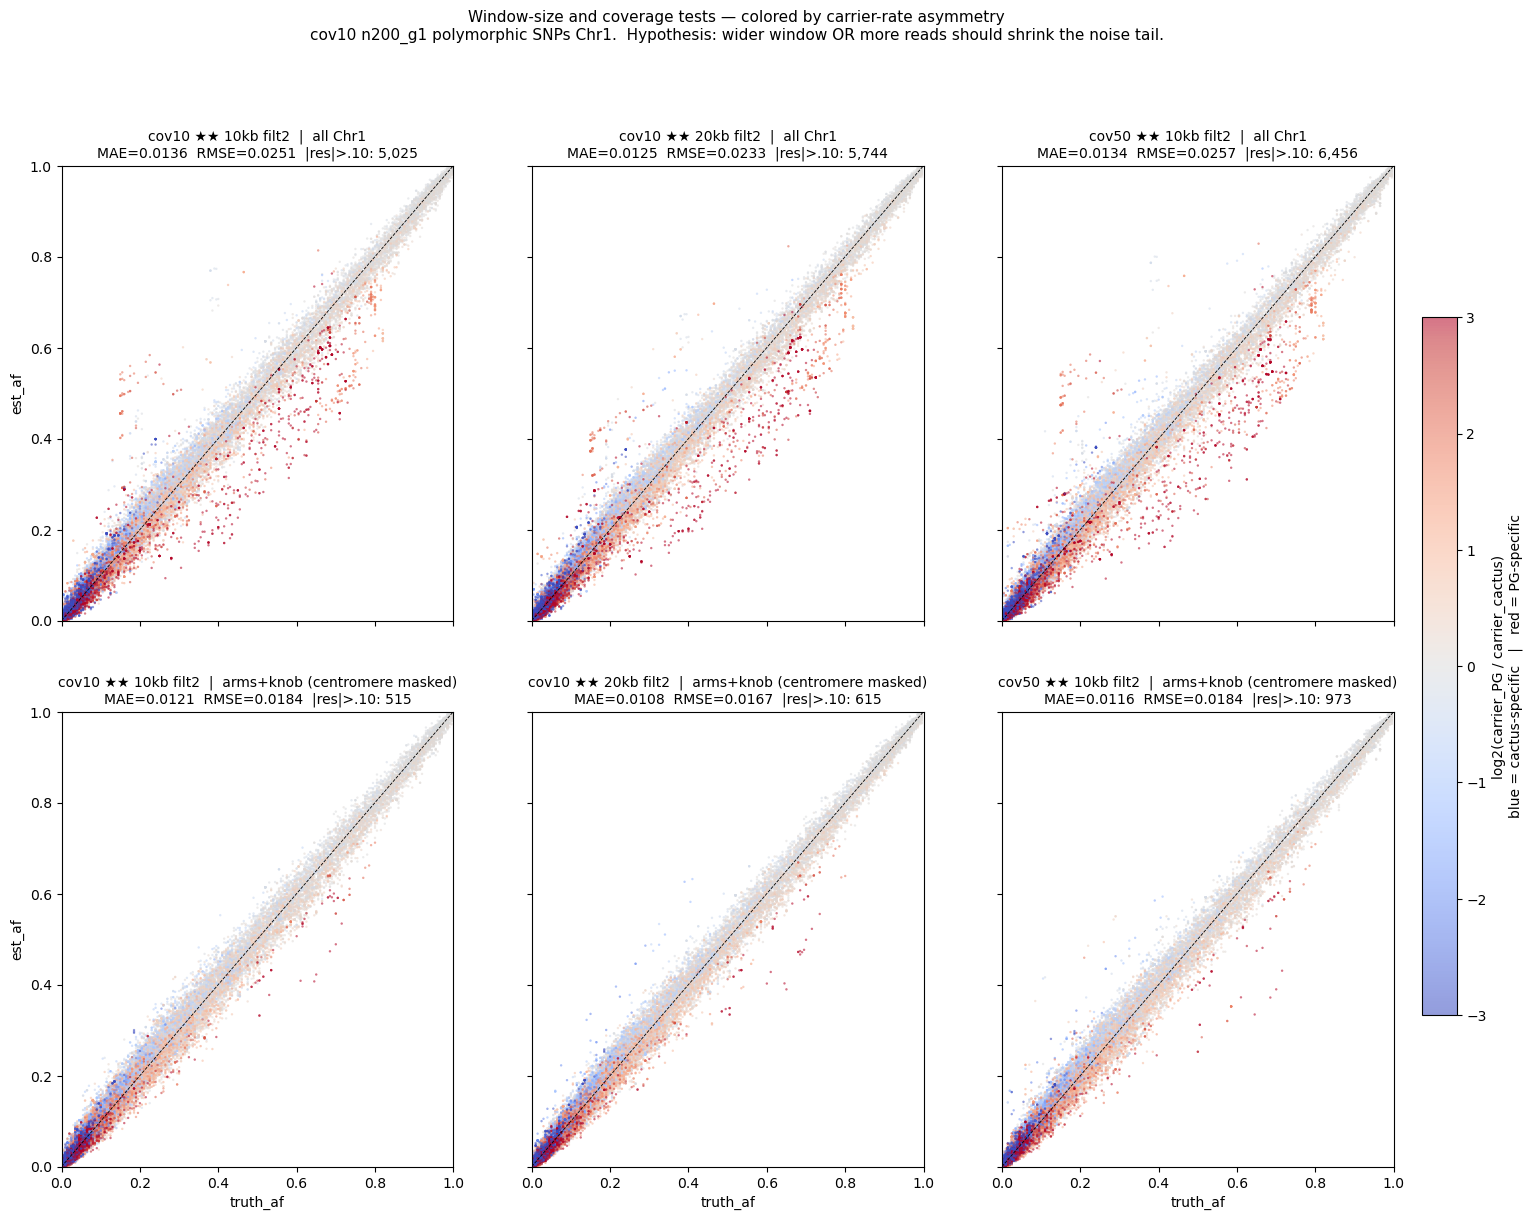

In [16]:
# Three columns: cov10 10kb (current), cov10 20kb (wider window), cov50 10kb (more reads)
# Two rows: full Chr1 (top), arms+knob (centromere masked, bottom)
N_PLOT = 80_000
configs = [
    ('cov10 ★★ 10kb filt2',  'star2_filt2'),
    ('cov10 ★★ 20kb filt2',  'cov10_w20kb_filt2'),
    ('cov50 ★★ 10kb filt2',  'cov50_w10kb_filt2'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 13), sharex=True, sharey=True)
for r_, (subset_name, subset_df) in enumerate([('all Chr1', snps),
                                                ('arms+knob (centromere masked)', snps[snps.region != 'centromere'])]):
    for c_, (label, col) in enumerate(configs):
        ax = axes[r_, c_]
        sub = subset_df.dropna(subset=[col])
        plot_sub = (sub.sample(min(len(sub), N_PLOT), random_state=42)
                       .sort_values('log2_pg_cactus', key=np.abs))
        sc = ax.scatter(plot_sub.truth_af, plot_sub[col],
                        c=plot_sub.log2_pg_cactus, cmap='coolwarm', vmin=-3, vmax=3,
                        s=3, alpha=0.55, rasterized=True, edgecolors='none')
        ax.plot([0,1],[0,1],'k--',lw=0.6)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        st = mtab(sub.truth_af.values, sub[col].values)
        ax.set_title(f'{label}  |  {subset_name}\n'
                     f'MAE={st["MAE"]:.4f}  RMSE={st["RMSE"]:.4f}  '
                     f'|res|>.10: {st["n_out_10"]:,}', fontsize=10)
        if r_ == 1: ax.set_xlabel('truth_af')
        if c_ == 0: ax.set_ylabel('est_af')
cb = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
cb.set_label('log2(carrier_PG / carrier_cactus)\nblue = cactus-specific   |   red = PG-specific')
fig.suptitle('Window-size and coverage tests — colored by carrier-rate asymmetry\n'
             'cov10 n200_g1 polymorphic SNPs Chr1.  Hypothesis: wider window OR more reads should shrink the noise tail.',
             y=1.00, fontsize=11)
plt.show()


## Coverage/window tests: scatter — colored by region

Same 2×3 grid, region coloring. Useful to compare which configuration is best per region (arms / knob / centromere).


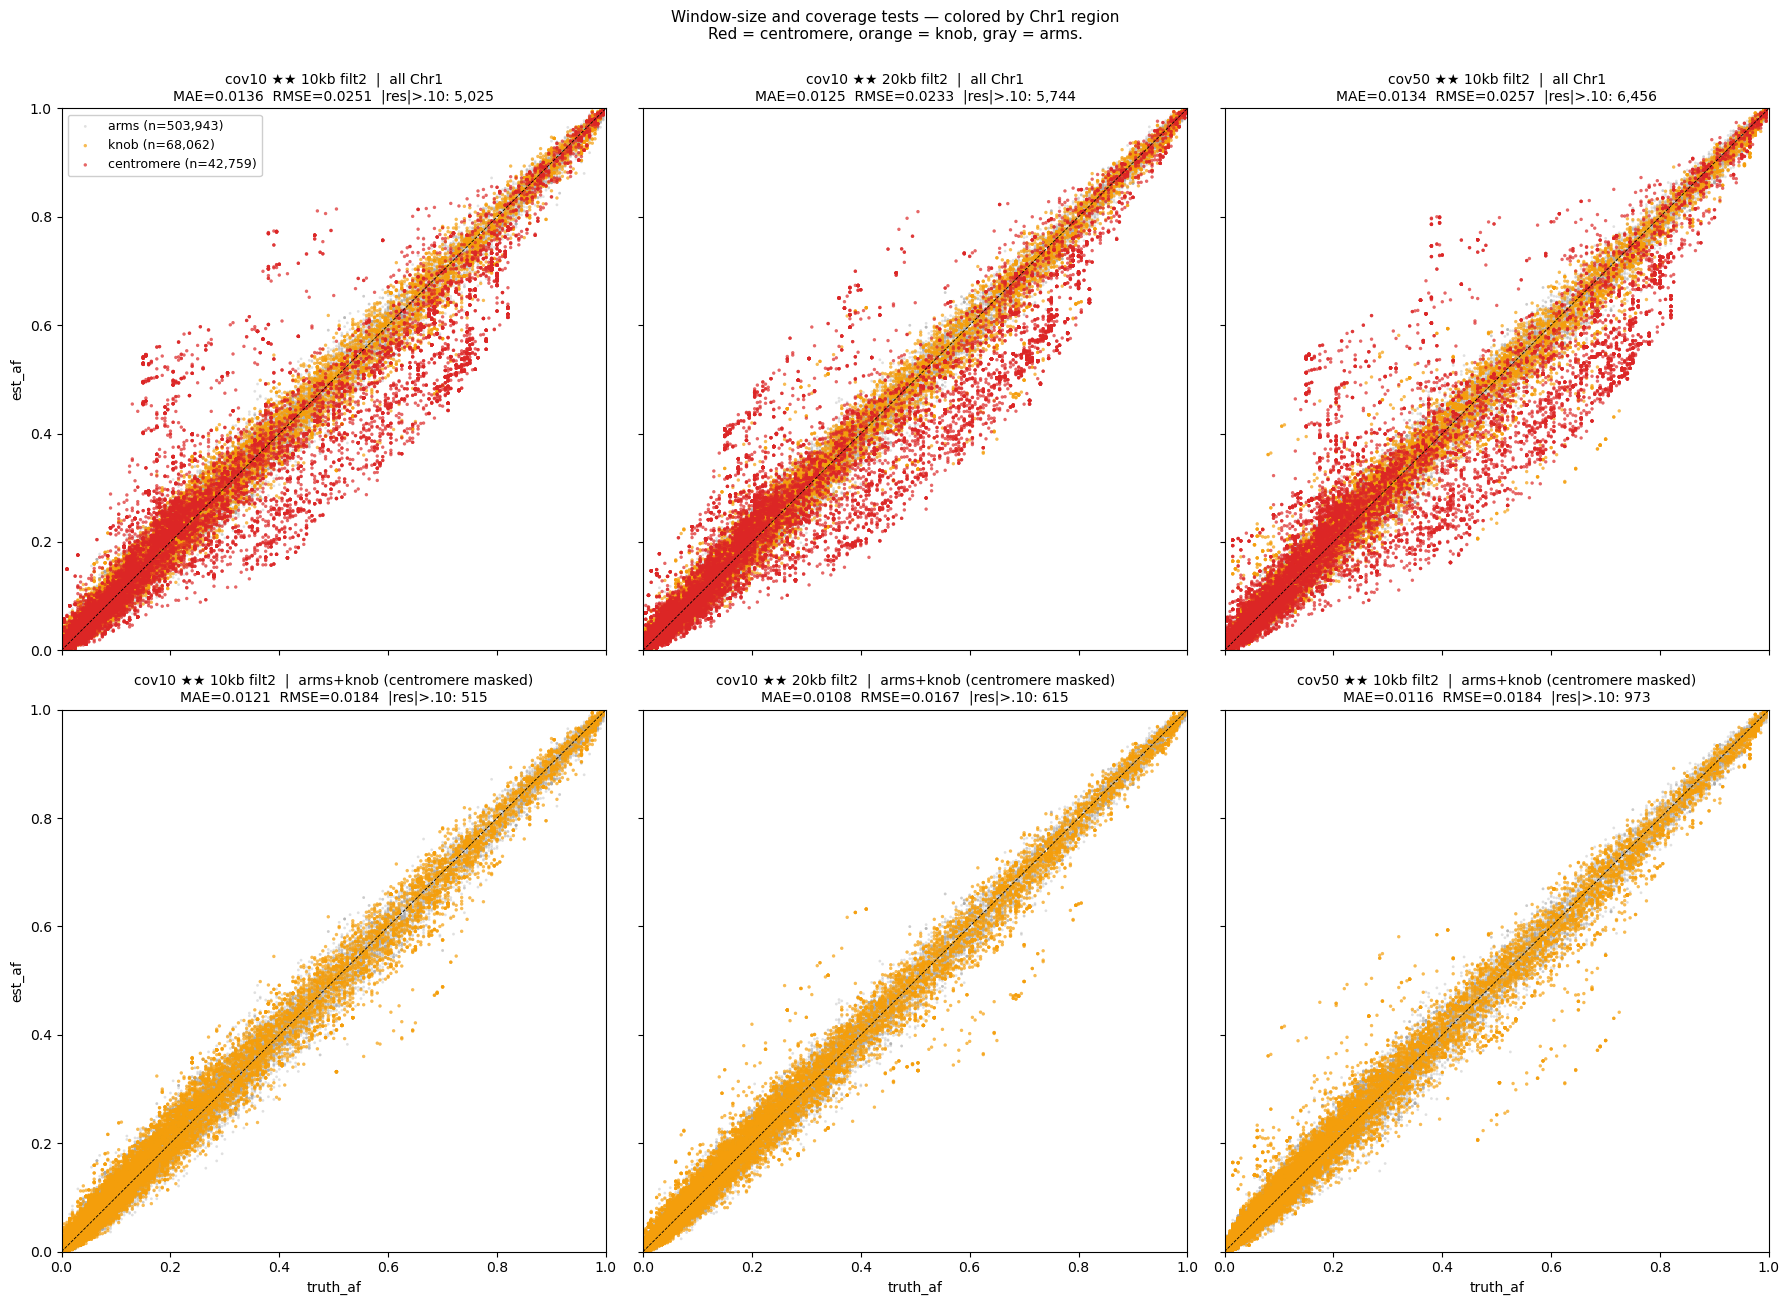

In [17]:
# Same 2x3 grid, region coloring
fig, axes = plt.subplots(2, 3, figsize=(18, 13), sharex=True, sharey=True)
for r_, (subset_name, subset_df) in enumerate([('all Chr1', snps),
                                                ('arms+knob (centromere masked)', snps[snps.region != 'centromere'])]):
    for c_, (label, col) in enumerate(configs):
        ax = axes[r_, c_]
        sub = subset_df.dropna(subset=[col])
        N_PLOT_PER_REGION = {'arms': 60_000, 'knob': 30_000, 'centromere': 30_000, 'other_chrom': 0}
        ORDER = ['arms','other_chrom','knob','centromere']
        for reg in ORDER:
            ss = sub[sub.region == reg]
            n_plot = min(len(ss), N_PLOT_PER_REGION.get(reg, 0))
            if n_plot == 0: continue
            plot_ss = ss.sample(n_plot, random_state=42)
            ax.scatter(plot_ss.truth_af, plot_ss[col],
                       c=REGION_COLOR[reg], s=4 if reg=='arms' else 6,
                       alpha=0.35 if reg=='arms' else 0.7,
                       edgecolors='none', rasterized=True,
                       label=f'{reg} (n={len(ss):,})' if r_==0 and c_==0 else None)
        ax.plot([0,1],[0,1],'k--',lw=0.6)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        st = mtab(sub.truth_af.values, sub[col].values)
        ax.set_title(f'{label}  |  {subset_name}\n'
                     f'MAE={st["MAE"]:.4f}  RMSE={st["RMSE"]:.4f}  '
                     f'|res|>.10: {st["n_out_10"]:,}', fontsize=10)
        if r_ == 1: ax.set_xlabel('truth_af')
        if c_ == 0: ax.set_ylabel('est_af')
axes[0, 0].legend(loc='upper left', fontsize=9, framealpha=0.95)
fig.suptitle('Window-size and coverage tests — colored by Chr1 region\n'
             'Red = centromere, orange = knob, gray = arms.',
             y=1.00, fontsize=11)
plt.tight_layout()
plt.show()


## Coverage/window tests: per-region MAE table

Quantitative per-region MAE for each configuration. Tells you which lever helps which region.


In [18]:
print(f'{"variant":<28s}  {"region":<11s}  {"n":>9s}  {"MAE":>7s}  {"RMSE":>7s}  {"|res|>.10":>10s}  {"rate%":>6s}')
for label, col in configs:
    for reg in ['arms','knob','centromere']:
        ss = snps[snps.region==reg].dropna(subset=[col])
        st = mtab(ss.truth_af.values, ss[col].values)
        print(f'{label:<28s}  {reg:<11s}  {len(ss):>9,}  {st["MAE"]:>7.4f}  {st["RMSE"]:>7.4f}  {st["n_out_10"]:>10,}  {100*st["n_out_10"]/max(len(ss),1):>6.2f}')
    print()


variant                       region               n      MAE     RMSE   |res|>.10   rate%
cov10 ★★ 10kb filt2           arms           503,943   0.0116   0.0176         248    0.05


cov10 ★★ 10kb filt2           knob            68,062   0.0155   0.0238         267    0.39
cov10 ★★ 10kb filt2           centromere      42,759   0.0344   0.0671       4,510   10.55



cov10 ★★ 20kb filt2           arms           503,943   0.0103   0.0155         120    0.02
cov10 ★★ 20kb filt2           knob            68,062   0.0144   0.0240         495    0.73
cov10 ★★ 20kb filt2           centromere      42,759   0.0347   0.0636       5,129   12.00



cov50 ★★ 10kb filt2           arms           503,943   0.0110   0.0167         252    0.05
cov50 ★★ 10kb filt2           knob            68,062   0.0160   0.0280         721    1.06
cov50 ★★ 10kb filt2           centromere      42,759   0.0372   0.0701       5,483   12.82



### Coverage/window tests: reading the result

- **cov50 ★★ ≈ cov10 ★★** in MAE and outlier counts. 5× more reads → ~0% improvement. The residual is NOT coverage-limited; per-window haplotype identifiability has saturated at cov10× already. (See `memory/project_cov50_does_not_help.md`.)
- **20kb DOES help arms**: more linked SNPs per window = better identifiability. MAE drops 8-11% on arms; outlier count nearly halves on arms.
- **20kb HURTS knob and centromere**: wider windows blend in adjacent bad-bubble noise.
- **No single change** kills the residual. The right next step depends on what region matters: 20kb wins for arms-only production; 10kb stays better for knob/centromere; a hybrid would be the natural follow-up if needed.


---

# Bottom line — production direction

## Three-source decomposition recap

| # | source | fix status | residual after fix |
|---|---|---|---|
| 1 | **Cactus-private k-mer pinning** | ✅ filt2 (drop carrier_count==1) — ~95% | +0.0005 cactus-specific bias |
| 2 | **Centromere alignment dead zone** | ❌ structural, not fixable at EM/cn level | ~10% outlier rate in Mb 14-17 (7% of polymorphic SNPs) |
| 3 | **PG identifiability deficit** | ⚠️ filt2 partial (~40%) | −0.014 PG-specific bias, concentrated in Chr1q knob |

## Negative-control conclusions

- cov50 vs cov10: 5× reads → 0% MAE improvement. Residual is information-saturated, not coverage-limited. (`memory/project_cov50_does_not_help.md`)
- 20kb vs 10kb windows: helps **arms** (more linkage info) but hurts **knob/centromere** (blends dead-zone noise into clean variants). Hybrid (10kb-knob+centromere / 20kb-arms) could be a follow-up, not a critical path.

## Practical production steps

1. **Build `cn_full_231_v3_filt2/` for all 5 chromosomes** (one-time, ~30 min compute; only Chr1 currently exists from the bug-investigation session).
2. **Switch production driver flag**: `--cn-kmer-prefix data/cn_full_231_v3_filt2/cn` instead of `cn_full_231_v3/cn`. No other pipeline changes; cn_var stays v3.
3. **Re-run the 2,415 evolved GrENE-Net samples + 8 SEEDMIX**.
4. **Live with the centromere residual**: ~7% of polymorphic Chr1 SNPs in Mb 14-17 have ~10% outlier rate. Downstream GEA should optionally flag or down-weight those.
5. **Live with the PG-specific bias** (~−0.014 on 4% of variants): manageable for GEA. Asymmetric filtering or founder pruning is an optional follow-up if needed.

## What we will not retry

- Row-normalize cn at EM-load time (sign-flips the bias — see `BALANCING_KMERS.md` §1)
- Beagle imputation of cn_full (hard-rejected for SVs — see `feedback_no_beagle_solutions.md`)
- More coverage at this regime (information-saturated — see `project_cov50_does_not_help.md`)
